In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/fraud-risk-platform/Base.csv"  # adjust filename
df = pd.read_csv(DATA_PATH)
df.shape

(1000000, 32)

In [3]:
print(df.shape)
print(df.columns.tolist())
df.head()

(1000000, 32)
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [4]:
target_col = "fraud_bool"  # adjust if your printed columns show a different name

counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percentages.round(3))

Counts:
 fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Percentages:
 fraud_bool
0    98.897
1     1.103
Name: proportion, dtype: float64


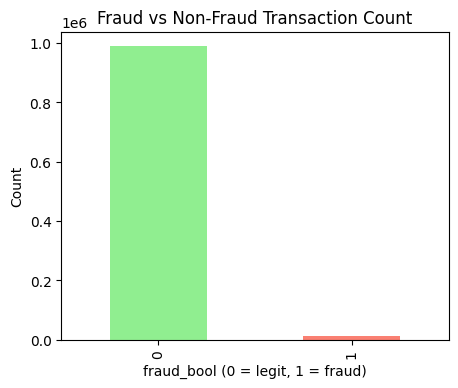

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
counts.plot(kind='bar', color=['lightgreen','salmon'])
plt.title('Fraud vs Non-Fraud Transaction Count')
plt.xlabel('fraud_bool (0 = legit, 1 = fraud)')
plt.ylabel('Count')
plt.savefig('/content/drive/MyDrive/fraud-risk-platform/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct


In [7]:
possible_sentinel_cols = ['prev_address_months_count', 'current_address_months_count',
                           'intended_balcon_amount', 'bank_months_count', 'session_length_in_minutes',
                           'device_distinct_emails_8w']

for col in possible_sentinel_cols:
    if col in df.columns:
        neg_one_count = (df[col] == -1).sum()
        print(f"{col}: {neg_one_count} rows with value -1 ({round(neg_one_count/len(df)*100, 2)}%)")

prev_address_months_count: 712920 rows with value -1 (71.29%)
current_address_months_count: 4254 rows with value -1 (0.43%)
intended_balcon_amount: 0 rows with value -1 (0.0%)
bank_months_count: 253635 rows with value -1 (25.36%)
session_length_in_minutes: 2015 rows with value -1 (0.2%)
device_distinct_emails_8w: 359 rows with value -1 (0.04%)


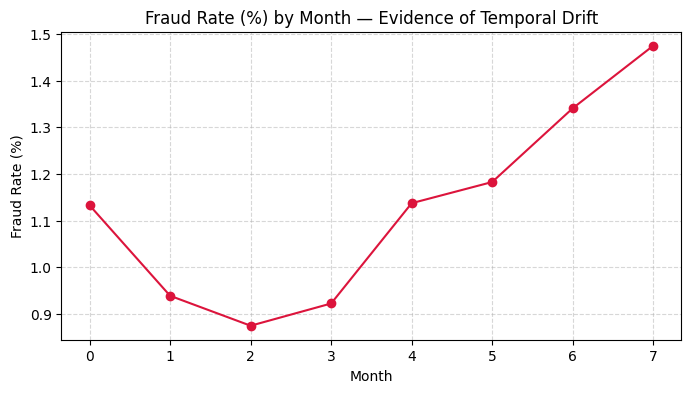

month
0    1.132588
1    0.938724
2    0.874587
3    0.922245
4    1.137120
5    1.182505
6    1.340507
7    1.474552
Name: fraud_bool, dtype: float64


In [8]:
month_col = "month"  # adjust if your printed columns show a different name

fraud_rate_by_month = df.groupby(month_col)[target_col].mean() * 100

plt.figure(figsize=(8,4))
fraud_rate_by_month.plot(kind='line', marker='o', color='crimson')
plt.title('Fraud Rate (%) by Month — Evidence of Temporal Drift')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/content/drive/MyDrive/fraud-risk-platform/fraud_rate_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraud_rate_by_month)

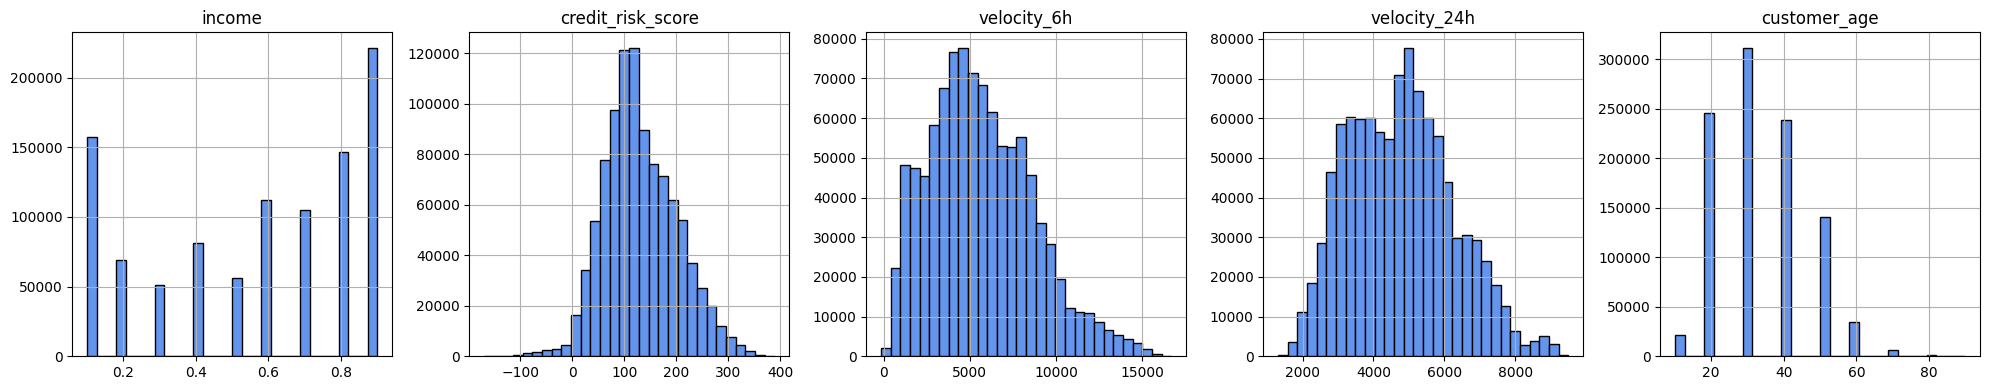

In [9]:
key_features = ['income', 'credit_risk_score', 'velocity_6h', 'velocity_24h', 'customer_age']
key_features = [c for c in key_features if c in df.columns]  # only keep ones that actually exist

fig, axes = plt.subplots(1, len(key_features), figsize=(4*len(key_features), 4))
for ax, col in zip(axes, key_features):
    df[col].hist(ax=ax, bins=30, color='cornflowerblue', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud-risk-platform/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_with_target = numeric_df.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(corr_with_target.head(15))

credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
keep_alive_session                 -0.050296
income                              0.045079
date_of_birth_distinct_emails_4w   -0.043224
name_email_similarity              -0.036720
device_distinct_emails_8w           0.035704
has_other_cards                    -0.035156
phone_home_valid                   -0.035128
current_address_months_count        0.033701
email_is_free                       0.027758
prev_address_months_count          -0.026031
intended_balcon_amount             -0.024524
velocity_6h                        -0.016892
Name: fraud_bool, dtype: float64
